# Olist Brazilian E-Commerce Data Visualization

**Internship** :   CodeAlpha

**Name**    : Mehwish Iqbal

**task_02**  :Data visulization

## Introduction

This project focuses on transforming Olist e-commerce data into clear and meaningful visualizations.

The objective is to identify sales trends, customer patterns, product performance, payment behavior, and delivery performance using Python visualization libraries.

The main **objectives** of this task are to:

* Transform raw data into meaningful charts and graphs.
* Use appropriate visualizations to communicate key findings clearly.
* Identify important trends, patterns, and comparisons through visual analysis.
* Create data stories that connect visual findings with business decisions.
* Develop clear and impactful visualizations suitable for a professional portfolio.


### Tools

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Load Datasets

In [31]:
orders = pd.read_csv('Downloads/olist_orders_dataset.csv')
order_items = pd.read_csv('Downloads/olist_order_items_dataset.csv')
products = pd.read_csv('Downloads/olist_products_dataset.csv')
customers = pd.read_csv('Downloads/olist_customers_dataset.csv')
payments = pd.read_csv("Downloads/olist_order_payments_dataset.csv")
category_translation = pd.read_csv(
    'Downloads/product_category_name_translation.csv'
)

In [32]:
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)
print("Category Translation:", category_translation.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Products: (32951, 9)
Category Translation: (71, 2)
Customers: (99441, 5)


### Data Preparation

The datasets were previously cleaned and validated during the Exploratory Data Analysis (EDA) task_01. For this visualization task, only the required preprocessing and dataset merging steps are repeated to prepare the data for visualization.

No additional data-cleaning or anomaly-detection analysis is performed here because the main focus of this task is data visualization and storytelling.


#### Convert Date Columns

In [33]:
# Orders date columns
order_date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Order items date column
order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date'],
    errors='coerce'
)

### Product Category Translation

In [34]:
products['product_category_name'] = (
    products['product_category_name']
    .fillna('unknown')
)

products = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

products['product_category_name_english'] = (
    products['product_category_name_english']
    .fillna('Unknown')
)

### Create  main sales_data

In [35]:
sales_data = order_items.merge(
    products[
        ['product_id', 'product_category_name_english']
    ],
    on='product_id',
    how='left'
).merge(
    orders[
        [
            'order_id',
            'customer_id',
            'order_status',
            'order_purchase_timestamp',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]
    ],
    on='order_id',
    how='left'
).merge(
    customers[
        [
            'customer_id',
            'customer_unique_id',
            'customer_city',
            'customer_state'
        ]
    ],
    on='customer_id',
    how='left'
)

In [36]:
sales_data.shape

(112650, 16)

In [37]:
sales_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP


---

#  Visulization

1)  Monthly Sales Revenue Trend
2) Top 10 Product Categories by Revenue
3) Top 10 States by Number of Customers
4) Payment Method Distribution
5) Orders by Day of the Week
6) Revenue by Day of the Week
7) Product Price vs Freight Value
8)   Top 10 Product Categories by Average Delivery Difference

## 1. Monthly Revenue Trend

To understand how sales performance changes over time, monthly revenue is visualized using a line chart.

This visualization helps identify periods of higher and lower sales and makes the overall revenue trend easier to understand.

The chart is based on the order purchase date and product sales price.


In [38]:
sales_data['order_purchase_timestamp'] = pd.to_datetime(
    sales_data['order_purchase_timestamp']
)

sales_data['purchase_month'] = (
    sales_data['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

In [39]:
monthly_revenue = (
    sales_data.groupby('purchase_month', as_index=False)['price']
    .sum()
)

In [40]:
monthly_revenue.head()

,purchase_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


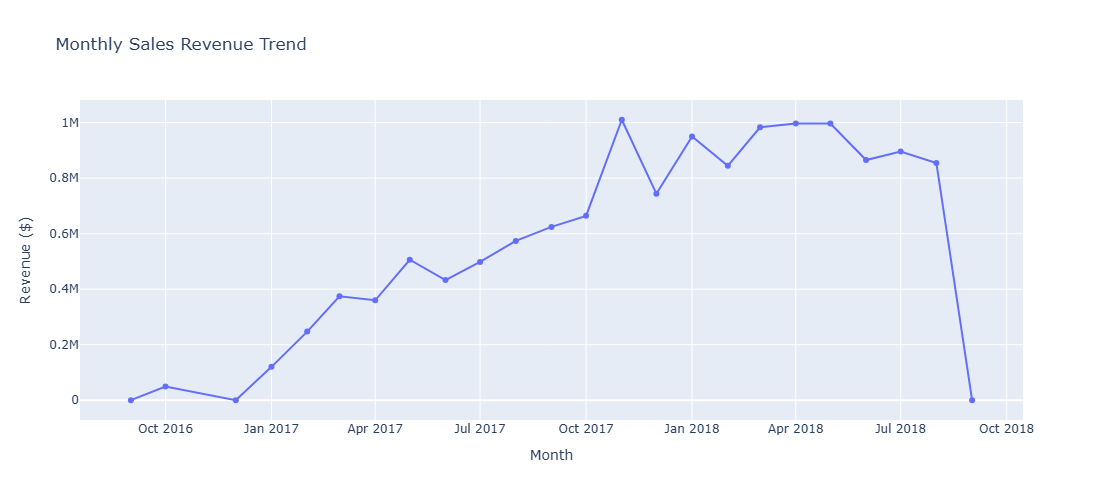

In [41]:
fig = px.line(
    monthly_revenue,
    x='purchase_month',
    y='price',
    markers=True,
    title='Monthly Sales Revenue Trend',
    labels={
        'purchase_month': 'Month',
        'price': 'Revenue ($)'
    },
    height=500,
    width= 1000
)

fig.show()

insight

* Sales revenue generally increased over time from J**an 2017** onword.
* Revenue peaked around **Nov 2017 (~$1.01M)**.
* Revenue remained high during 2018, with a decline toward the final month.

------

## 2. Top 10 Product Categories by Revenue

To identify the strongest product categories, the top 10 categories are visualized based on total sales revenue.

This bar chart makes it easier to compare category performance and identify the categories contributing the most revenue.


In [42]:
category_revenue = (
    sales_data.groupby('product_category_name_english')['price']
    .sum()
    .nlargest(10)
)

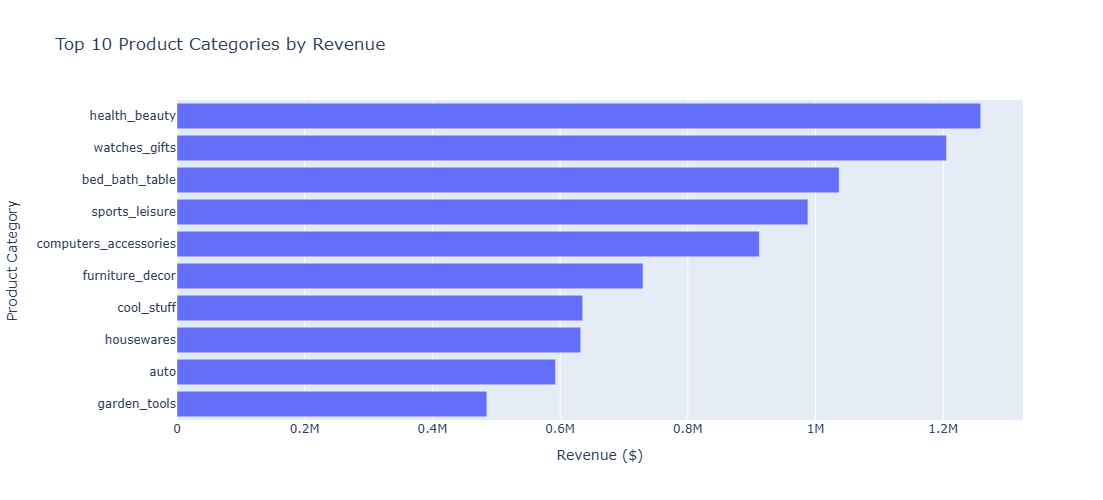

In [43]:
fig = px.bar(
    category_revenue.sort_values(),
    x=category_revenue.sort_values().values,
    y=category_revenue.sort_values().index,
    orientation='h',
    title='Top 10 Product Categories by Revenue',
    labels={
        'x': 'Revenue ($)',
        'y': 'Product Category'
    },
    height=500,
    width=1000
)

fig.show()

**Insight:**

* Health & Beauty had the highest revenue at $1.26M,

* while  Garden Tools  had the lowest at $485K
among the top 10 categories.


---

## 3. Top 10 States by Customers

This visualization shows the top 10 Brazilian states based on the number of customers.

It helps identify the states where the e-commerce platform has the largest customer base.

In [44]:
# Number of customers by state
state_customers = sales_data['customer_state'].value_counts()

In [45]:
import plotly.express as px

# Top 10 states by number of customers
top_10_states = state_customers.head(10).sort_values()

fig = px.bar(
    x=top_10_states.values,
    y=top_10_states.index,
    orientation='h',
    title='Top 10 States by Number of Customers',
    labels={
        'x': 'Number of Customers',
        'y': 'State'
    },
    text=top_10_states.values
)

fig.update_traces(
    texttemplate='%{x:,}',
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Customers: %{x:,}<extra></extra>'
)

fig.update_layout(
    template='plotly_white',
    height=500,
    width=1100
)

fig.show()

**Insight:** 

São Paulo (SP) had the highest number of customers (47,449), followed by RJ (14,579) and MG (13,129).


---

## 4. Payment Method Distribution

To understand customer payment preferences, the distribution of payment methods is visualized based on the number of payment records.

This visualization shows which payment methods are used most frequently by customers.

In [46]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [47]:
# Count of payment methods
payment_counts = payments['payment_type'].value_counts()

payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [48]:
fig = px.pie(
    payment_counts,
    names=payment_counts.index,
    values=payment_counts.values,
    title='Payment Method Distribution'
)

fig.update_layout(
    height=600,
    width=900
)

fig.show()

**Insight:**

Credit cards were the most used payment method (76,795 transactions), while debit cards had the lowest usage (1,529).

---

### 5) Orders by Day of the Week

In [49]:
# Extract the day of the week from the order purchase timestamp

orders['purchase_day'] = (
    orders['order_purchase_timestamp']
    .dt.day_name()
)

orders[['order_id', 'purchase_day']].head()

,order_id,purchase_day
0,e481f51cbdc54678b7cc49136f2d6af7,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,Tuesday


In [50]:
# Count orders for each day of the week

day_orders = (
    orders['purchase_day']
    .value_counts()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
    .reset_index()
)

day_orders.columns = [
    'day_of_week',
    'order_count'
]

day_orders

,day_of_week,order_count
0,Monday,16196
1,Tuesday,15963
2,Wednesday,15552
3,Thursday,14761
4,Friday,14122
5,Saturday,10887
6,Sunday,11960


In [51]:
import plotly.express as px

fig = px.bar(
    day_orders,
    x='day_of_week',
    y='order_count',
    title='Orders by Day of the Week',
    labels={
        'day_of_week': 'Day of Week',
        'order_count': 'Number of Orders'
    },
    text='order_count'
)

fig.update_traces(
    texttemplate='%{y:,}',
    textposition='outside',
    hovertemplate=(
        '<b>%{x}</b><br>'
        'Orders: %{y:,}'
        '<extra></extra>'
    )
)

fig.update_layout(
    template='plotly_white',
    height=500,
    width=1000
)

fig.show()

**Insight:**

Monday had the highest order volume with **16,196 orders**, while Saturday had the lowest with **10,887 orders**, showing stronger customer activity at the beginning of the week.

---

### 6) Revenue by Day of the Week

In [52]:
# Convert timestamp to datetime
sales_data['order_purchase_timestamp'] = pd.to_datetime(
    sales_data['order_purchase_timestamp']
)

# Extract day of week
sales_data['purchase_day'] = (
    sales_data['order_purchase_timestamp'].dt.day_name()
)

# Arrange days from Monday to Sunday
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Calculate revenue by day
day_revenue = (
    sales_data.groupby('purchase_day')['price']
    .sum()
    .reindex(day_order)
)

# Line chart
fig = px.line(
    x=day_revenue.index,
    y=day_revenue.values,
    markers=True,
    title='Revenue by Day of Week',
    labels={
        'x': 'Day of Week',
        'y': 'Revenue ($)'
    },
    height=500,
    width=1000
)

# Hover information
fig.update_traces(
    hovertemplate='<b>%{x}</b><br>Revenue: $%{y:,.2f}<extra></extra>'
)

fig.show()

**Insight:**

Monday generated the highest revenue at **$2.23M**, while Saturday recorded the lowest at 

**$1.50M**, showing stronger revenue performance at the beginning of the week.


---

## 7) Product Price vs Freight Value

In [53]:
# Select a sample of data for better visualization

plot_data = sales_data.sample(
    min(5000, len(sales_data)),
    random_state=42
)

plot_data[
    ['product_category_name_english', 'price', 'freight_value']
].head(10)

,product_category_name_english,price,freight_value
107777,watches_gifts,180.00,20.45
2391,furniture_decor,10.99,16.05
77829,furniture_living_room,49.99,8.88
99819,auto,117.30,14.43
41297,toys,58.90,13.77
111433,computers_accessories,79.99,17.81
18924,watches_gifts,169.99,17.76
102447,electronics,19.90,15.10
33507,office_furniture,159.94,41.11
49559,watches_gifts,223.00,19.44


In [54]:
import plotly.express as px

fig = px.scatter(
    plot_data,
    x='price',
    y='freight_value',
    title='Product Price vs Freight Value',
    labels={
        'price': 'Product Price ($)',
        'freight_value': 'Shipping/Freight Value ($)',
        'product_category_name_english': 'Product Category'
    },
    custom_data=['product_category_name_english'],
    opacity=0.6
)

fig.update_traces(
    hovertemplate=(
        '<b>Product Category:</b> %{customdata[0]}<br>'
        '<b>Product Price:</b> $%{x:.2f}<br>'
        '<b>Shipping/Freight Value:</b> $%{y:.2f}'
        '<extra></extra>'
    )
)

fig.update_layout(
    template='plotly_white',
    height=500,
    width=1000
)

fig.show()

**Insight:** 

The scatter plot shows **variation in freight value across different product prices**, with some products having relatively high freight costs even at lower price points.


---

## 8) Top 10 Product Categories by Average Delivery Difference



  **Note**

 Calculate delivery difference in days
* Positive = Late
* Zero = On estimated date
* Negative = Early

In [55]:


sales_data['delivery_delay_days'] = (
    sales_data['order_delivered_customer_date']
    - sales_data['order_estimated_delivery_date']
).dt.days

In [56]:
# Calculate delivery difference in days

sales_data['delivery_delay_days'] = (
    sales_data['order_delivered_customer_date']
    - sales_data['order_estimated_delivery_date']
).dt.days

# Create a readable delivery status column

sales_data['delivery_difference'] = sales_data['delivery_delay_days'].apply(
    lambda x: (
        f"{abs(x)} days early" if x < 0
        else "On estimated date" if x == 0
        else f"{x} days late"
    )
)

sales_data[
    [
        'product_category_name_english',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'delivery_delay_days',
        'delivery_difference'
    ]
].head(10)

,product_category_name_english,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,delivery_difference
0,cool_stuff,2017-09-20 23:43:48,2017-09-29,-9.0,9.0 days early
1,pet_shop,2017-05-12 16:04:24,2017-05-15,-3.0,3.0 days early
2,furniture_decor,2018-01-22 13:19:16,2018-02-05,-14.0,14.0 days early
3,perfumery,2018-08-14 13:32:39,2018-08-20,-6.0,6.0 days early
4,garden_tools,2017-03-01 16:42:31,2017-03-17,-16.0,16.0 days early
5,housewares,2017-05-22 13:44:35,2017-06-06,-15.0,15.0 days early
6,telephony,2017-12-18 22:03:38,2018-01-04,-17.0,17.0 days early
7,garden_tools,2018-07-09 14:04:07,2018-07-25,-16.0,16.0 days early
8,health_beauty,2018-03-29 18:17:31,2018-03-29,0.0,On estimated date
9,books_technical,2018-07-04 17:28:31,2018-07-23,-19.0,19.0 days early


In [57]:
import plotly.express as px

category_delivery = (
    sales_data.groupby(
        'product_category_name_english',
        as_index=False
    )['delivery_delay_days']
    .mean()
)

category_delivery.columns = [
    'product_category',
    'average_delivery_difference'
]

top_categories = category_delivery.head(10).sort_values(
    'average_delivery_difference'
)

# Create readable labels for the chart

top_categories['delivery_difference'] = top_categories[
    'average_delivery_difference'
].apply(
    lambda x: (
        f"{abs(x):.1f} days early" if x < 0
        else "On estimated date" if x == 0
        else f"{x:.1f} days late"
    )
)

fig = px.bar(
    top_categories,
    x='average_delivery_difference',
    y='product_category',
    orientation='h',
    title='Top 10 Product Categories by Average Delivery Difference',
    labels={
        'average_delivery_difference': 'Delivery Difference (Days)',
        'product_category': 'Product Category'
    },
    text='delivery_difference'
)

fig.update_traces(
    textposition='outside',
    hovertemplate=(
        '<b>Category:</b> %{y}<br>'
        '<b>Delivery Difference:</b> %{text}'
        '<extra></extra>'
    )
)

fig.add_vline(
    x=0,
    line_dash='dash',
    annotation_text='Estimated Date'
)

fig.update_layout(
    template='plotly_white',
    height=500,
    width=1000
)

fig.show()

### Insight

* All top 10 product categories show **negative average delivery differences**, indicating that orders were delivered **earlier than their estimated delivery dates** on average.
* **air_conditioning** had the largest early-delivery difference at approximately **14.2 days early**.
* **Arts & Craftmanship** had the smallest early-delivery difference among the top 10, at approximately **6.8 days early**.

---


# Data Story & Business Decisions

The analysis reveals a clear business story across sales, products, customers, payments, and operations.

* **Monday generated the highest revenue of $2.23M from 16,196 orders**,

     suggesting stronger demand at the beginning of the week.

* **Saturday recorded the lowest revenue at $1.50M**, indicating lower weekend activity.

* **Health & Beauty generated the highest category revenue of $1.26M**, highlighting a key product category.

* **São Paulo (SP) had the highest customer base with 39,981 customers**, identifying an important regional market.
* **Credit cards accounted for 76,795 transactions**, showing a strong preference for this payment method.

* The top 10 product categories showed average delivery differences of approximately **6.8–14.2 days early**.

### Business Decisions

These findings can support decisions to **focus on high-performing products and regions, schedule promotions around high-demand periods, prioritize popular payment options, and improve delivery planning**.

Overall, the visualizations connect different aspects of the business into a clear data story that supports **practical, data-driven decision-making**.


**thanks**